# Introduction to Data Science – Homework 5
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, February 20, 2026, 11:59pm.

In this homework you will use linear regression to study house prices in Salt Lake City.

## Your Data
Fill out the following information: 

*First Name:*   Ibrahim
*Last Name:*   Ergin
*E-mail:*   u1564808@utah.edu
*UID:*  u1564808


# Importing all the libraries 

In [38]:
# imports and setup 
import pandas as pd
import scipy as sc
import numpy as np

import statsmodels.formula.api as sm

#%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.style.use('ggplot')
%matplotlib inline  
plt.rcParams['figure.figsize'] = (10, 6) 

# Display settings for pandas DataFrames
# I' m using VSCode's Jupyter Notebook interface, so I want to see all the data without truncation.
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)    # No width limit
pd.set_option('display.expand_frame_repr', False)   # Don't wrap to multiple lines

## Regression of real estate data
For this problem, you will analyze SLC real estate data. The dataset contains multiple listing service (MLS) real estate transactions for houses sold in recent years in zip code 84103 ([SLC avenues neighborhood](https://www.google.com/maps/place/Salt+Lake+City,+UT+84103/@40.8030372,-111.8957957,12z/data=!3m1!4b1!4m5!3m4!1s0x87525f672006dded:0x311e638d9a1a2de5!8m2!3d40.810506!4d-111.8449346)). We are primarily interested in regressing the `SoldPrice` on the house attributes (`property size`, `house size`, `number of bedrooms`, etc...). 


### Task 1.1: Import the data 
Use the [`pandas.read_csv()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) function to import the dataset. The data is contained in two files located in the same directory as this notebook: [`train1.csv`](train1.csv) and [`train2.csv`](train2.csv). After you import these files separately, concatenate them into one big dataframe. This pandas dataframe will be used for data exploration and linear regression. 

In [39]:
df1 = pd.read_csv('train1.csv')
df2 = pd.read_csv('train2.csv')
merged_df = pd.concat([df1, df2], ignore_index=True)
print(f"train1.csv shape: {df1.shape}")
print(f"train2.csv shape: {df2.shape}")
print(f"Merged dataframe shape: {merged_df.shape}")

train1.csv shape: (277, 172)
train2.csv shape: (278, 172)
Merged dataframe shape: (555, 172)


# Task 1.2: Understand the Data

Now that the data is loaded. Try to understand the data. Domain knowledge is always important for most data science tasks.

- Print different information and statistics of the data (i.e. df.head(), df.info(), df.describe(), df.shape, df.columns etc.). There are 172 different variables associated with each of the 555 houses in this dataset. Skim them and try to get a rough understanding of what information this dataset contains. If you've never seen a real estate listing before, you might take a look at one on [utahrealstate.com](http://www.utahrealestate.com/) website to get a better sense of the meanings of the column headers in the dataset.  

- Print all the columns of the data

In [40]:
print(f"Merged dataframe columns: {merged_df.columns.tolist()}")
print("*-"*50)
print(f"Merged dataframe data types:\n{merged_df.dtypes}")
print("*-"*50)
print(f"Merged dataframe info: {merged_df.info()}")
print("*-"*50)
print(f"Merged dataframe description: {merged_df.describe(include='all')}")
print("*-"*50)
print(f"Merged dataframe missing values:\n{merged_df.isnull().sum()}")
print("*-"*50)
print(merged_df.head())

Merged dataframe columns: ['MLS_', 'Driveway', 'Acres', 'Air_Conditioning', 'Amenities', 'Area', 'Back_Dimensions', 'Basement', 'Basement_Finished', 'Canceled_Date', 'City', 'Contact_Phone_One', 'Contact_Phone_Two', 'Contact', 'Under_Contract_Date', 'County', 'Carport_Capacity', 'DOM', 'Decks', 'Pre_directional', 'Post_directional', 'East_West_Coordinates', 'Entered_By', 'Entry_Date', 'Exclusions', 'Expiration_Date', 'Exterior', 'Exterior_Features', 'Interior_Features', 'Floor', 'Front_Dimensions', 'Garage_Capacity', 'Garage_Parking', 'HOA_Fee', 'HOA_Terms', 'Heating', 'House_Number', 'Photo', 'Inclusions', 'Irregular_Shape', 'Landscape', 'Effective_Date_Of_The_Listing_Agreement', 'Listing_Type', 'Lot_Facts', 'Sold_Price', 'Listing_Price', 'North_South_Coordinates', 'Active_No_Show_Date', 'Office', 'Owner', 'Main_Floor_Bedrooms', 'Main_Floor_Full_Bathrooms', 'Main_Floor_Half_Bathrooms', 'Main_Floor_Three_quarter_Bathrooms', 'Main_Floor_Fireplaces', 'Main_Floor_Square_Feet', 'Main_Floor

### Task 2: Clean the data 

- Only keep houses with Listing Price between 300,000 and 900,000 dollars both inclusive; use **and** condition to filter out the rest. This is an arbitrary choice and we realize that some people are high rollers, but for our purposes we'll consider the others as outliers. 

- Remove columns that you don't think contribute to the value of the house. This is a personal decision – what attributes of a house are important to you? 
You should at least keep the following variables since questions below will use them: `['Acres', 'Back_Dimensions', 'Total_Kitchens', 'East_West_Coordinates', 'North_South_Coordinates', 'DOM', 'Sold_Price', 'Parking_Capacity', 'Property_Type', 'Listing_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']` 

- Check the datatypes and convert any numbers that were read as strings to numerical values. (Hint: You can use [`str.replace()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.str.replace.html) to work with strings.) If there are any categorical values you're interested in, then you should convert them to numerical values as in Lecture. In particular, convert 'Total Square Feet' to an integer and add a column titled `Property_Type_Num` that is 
$$
\text{Property\_Type\_Num}_i = \begin{cases} 
2 & \text{if $i$-th listing is a Townhouse} \\
1 & \text{if $i$-th listing is a Condo} \\
0 & \text{if $i$-th listing is a Single Family}
\end{cases}. 
$$

- Drop all rows with `Estimated_Taxes` = 1.

In [41]:
filtered_listing_price_merged_df = merged_df[(merged_df['Listing_Price'] >= 300000) & (merged_df['Listing_Price'] <= 900000)]
print(f"Listing price between 300,000 and 900,000 df shape: {filtered_listing_price_merged_df.shape}")
print("*-"*50)

filters = ['Acres', 'Back_Dimensions', 'Total_Kitchens', 'East_West_Coordinates', 'North_South_Coordinates', 'DOM', 'Sold_Price', 'Parking_Capacity', 'Property_Type', 'Listing_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']
filtered_df = filtered_listing_price_merged_df[filters]
print(f"Filtered columns df shape: {filtered_df.shape}")
print(f"Filtered dataframe columns: {filtered_df.columns.tolist()}")
print("*-"*50)
# Check for missing values in the filtered dataframe
print(f"Filtered dataframe missing values:\n{filtered_df.isnull().sum()}")



Listing price between 300,000 and 900,000 df shape: (349, 172)
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
Filtered columns df shape: (349, 15)
Filtered dataframe columns: ['Acres', 'Back_Dimensions', 'Total_Kitchens', 'East_West_Coordinates', 'North_South_Coordinates', 'DOM', 'Sold_Price', 'Parking_Capacity', 'Property_Type', 'Listing_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
Filtered dataframe missing values:
Acres                       0
Back_Dimensions             0
Total_Kitchens              0
East_West_Coordinates       0
North_South_Coordinates     0
DOM                        29
Sold_Price                  0
Parking_Capacity            0
Property_Type               0
Listing_Price               0
Estimated_Taxes             8
Total_Bedrooms              0
Total_Bath

In [42]:
# Depending on the amount of missing data, we can decide how to handle it. For now, let's drop rows with any missing values.
filtered_df = filtered_df.dropna()
print(f"Filtered dataframe missing values:\n{filtered_df.isnull().sum()}")
print(f"Filtered dataframe shape after dropping missing values: {filtered_df.shape}")
print("*-"*50)
print(f"Filtered dataframe dtypes:\n{filtered_df.dtypes}")
print("*-"*50)
print(filtered_df.head())

Filtered dataframe missing values:
Acres                      0
Back_Dimensions            0
Total_Kitchens             0
East_West_Coordinates      0
North_South_Coordinates    0
DOM                        0
Sold_Price                 0
Parking_Capacity           0
Property_Type              0
Listing_Price              0
Estimated_Taxes            0
Total_Bedrooms             0
Total_Bathrooms            0
Total_Square_Feet          0
Year_Built                 0
dtype: int64
Filtered dataframe shape after dropping missing values: (316, 15)
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
Filtered dataframe dtypes:
Acres                      float64
Back_Dimensions            float64
Total_Kitchens               int64
East_West_Coordinates        int64
North_South_Coordinates      int64
DOM                        float64
Sold_Price                   int64
Parking_Capacity             int64
Property_Type               object
Listing_

In [43]:
# Before converting Total_Square_Feet to numeric, let's check if there are any non-numeric entries in that column.
print(filtered_df['Total_Square_Feet'].head(10))  # Check the first 10 entries to see if there are any non-numeric values])

0     1,648
2       826
5     2,602
7     1,010
10    1,200
11      952
12    2,283
15    1,385
16    1,500
18      980
Name: Total_Square_Feet, dtype: object


In [44]:
filtered_df['Total_Square_Feet'] = filtered_df['Total_Square_Feet'].str.replace(',', '')  # Remove commas

In [45]:
# Let's convert Total_Square_Feet to numeric, just in case there are any non-numeric entries that got through.
filtered_df['Total_Square_Feet'] = pd.to_numeric(filtered_df['Total_Square_Feet'], errors='coerce')
print(f"Filtered dataframe dtypes after conversion:\n{filtered_df.dtypes}")
print("*-"*50)
print(filtered_df['Total_Square_Feet'].head())

Filtered dataframe dtypes after conversion:
Acres                      float64
Back_Dimensions            float64
Total_Kitchens               int64
East_West_Coordinates        int64
North_South_Coordinates      int64
DOM                        float64
Sold_Price                   int64
Parking_Capacity             int64
Property_Type               object
Listing_Price              float64
Estimated_Taxes            float64
Total_Bedrooms               int64
Total_Bathrooms              int64
Total_Square_Feet            int64
Year_Built                   int64
dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
0     1648
2      826
5     2602
7     1010
10    1200
Name: Total_Square_Feet, dtype: int64


In [46]:
# Property_Type is a categorical variable with Townhouse, Condo, Single Family. We need to add another column which is Property_Type_Num with numeric values.
print(f"Unique values in Property_Type before mapping: {filtered_df['Property_Type'].unique()}")
property_type_mapping = {'Townhouse': 2, 'Condo': 1, 'Single Family': 0}
filtered_df['Property_Type_Num'] = filtered_df['Property_Type'].map(property_type_mapping)
print(f"Unique values in Property_Type_Num after mapping: {filtered_df['Property_Type_Num'].unique()}")
print(f"Filtered dataframe dtypes after mapping Property_Type and adding Property_Type_Num column:\n{filtered_df.dtypes}")
print("*-"*50)
print(filtered_df.head())

Unique values in Property_Type before mapping: ['Condo' 'Townhouse' 'Single Family']
Unique values in Property_Type_Num after mapping: [1 2 0]
Filtered dataframe dtypes after mapping Property_Type and adding Property_Type_Num column:
Acres                      float64
Back_Dimensions            float64
Total_Kitchens               int64
East_West_Coordinates        int64
North_South_Coordinates      int64
DOM                        float64
Sold_Price                   int64
Parking_Capacity             int64
Property_Type               object
Listing_Price              float64
Estimated_Taxes            float64
Total_Bedrooms               int64
Total_Bathrooms              int64
Total_Square_Feet            int64
Year_Built                   int64
Property_Type_Num            int64
dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
    Acres  Back_Dimensions  Total_Kitchens  East_West_Coordinates  North_South_Coordinates 

In [47]:
#Drop all rows with `Estimated_Taxes` = 1
filtered_df.drop(filtered_df[filtered_df['Estimated_Taxes'] == 1].index, inplace=True)
print(f"Filtered dataframe shape after dropping rows with Estimated_Taxes = 1: {filtered_df.shape}")
print(f"Filtered dataframe head after dropping rows with Estimated_Taxes = 1:\n{filtered_df.head()}")

Filtered dataframe shape after dropping rows with Estimated_Taxes = 1: (309, 16)
Filtered dataframe head after dropping rows with Estimated_Taxes = 1:
    Acres  Back_Dimensions  Total_Kitchens  East_West_Coordinates  North_South_Coordinates   DOM  Sold_Price  Parking_Capacity Property_Type  Listing_Price  Estimated_Taxes  Total_Bedrooms  Total_Bathrooms  Total_Square_Feet  Year_Built  Property_Type_Num
0    0.01              0.0               0                     36                      245  21.0      825000                 0         Condo       825000.0           2485.0               2                2               1648        1976                  1
2    0.01              0.0               0                    300                      650  40.0      319900                 1         Condo       319900.0           1605.0               2                1                826        1961                  1
5    0.11              0.0               1                     78                

### Task 3: Exploratory data analysis and Visulization

- Make a bar chart showing the breakdown of the different types of houses (single family, townhouse, condo). 

- Compute the correlation matrix and use a heat map to visualize the correlation coefficients. 
    - Use a diverging color scale from -1 to +1 (see `vmin` and `vmax` parameters for [pcolor](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.pcolor.html))
    - Show a legend
    - Make sure the proper labels are visible and readable (see [`xticks`](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.xticks.html) and the corresponding [`yticks`](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.yticks.html)).
    - Keep in mind correlation can be calculated among features with numercial values.

- Make a scatter plot matrix to visualize the correlations.

    - Color-code the dots by property type. For the plot, only use a subset of the columns: `['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']`.
    - Determine which columns have strong correlations.
    - Set diagonal='kde' and explain what the diagonal plots are.

- Describing your findings.
#### Optional Task
Another great way to visualize the correlations is using scatter plot matrix. If you color-code the dots by property type and draw the distribution of the variable in the diagonal cells of the matrix, you will see a beautiful graph of correlations (Hint: Use `pd.plotting.scatter_matrix`). You should use only a subset of the columns: `['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price', 'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms', 'Total_Square_Feet', 'Year_Built']`. 

**Hint**: Use the code beloww to create a color map.

```python
type_color_map = red["Property_Type"].map({"Single Family":"#ca0020", "Condo":"#0571b0", "Townhouse":"#1b7837"})
```

And then use that as color in the plotting function like below

```python
pd.plotting.scatter_matrix(df, figsize=figsize, diagonal='kde', color=type_color_map)` function.
```


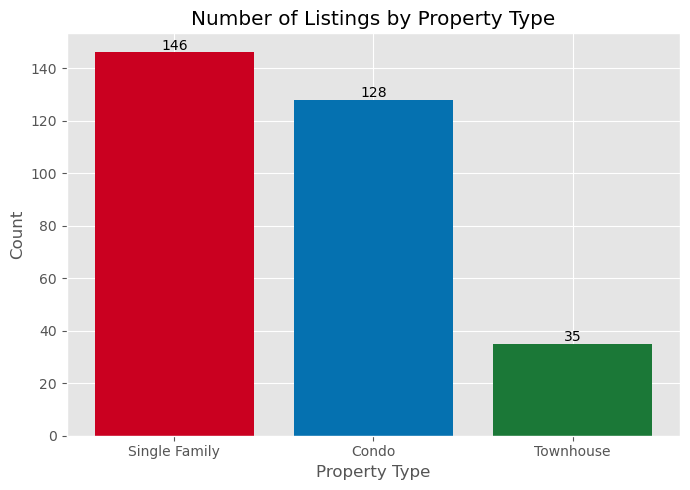

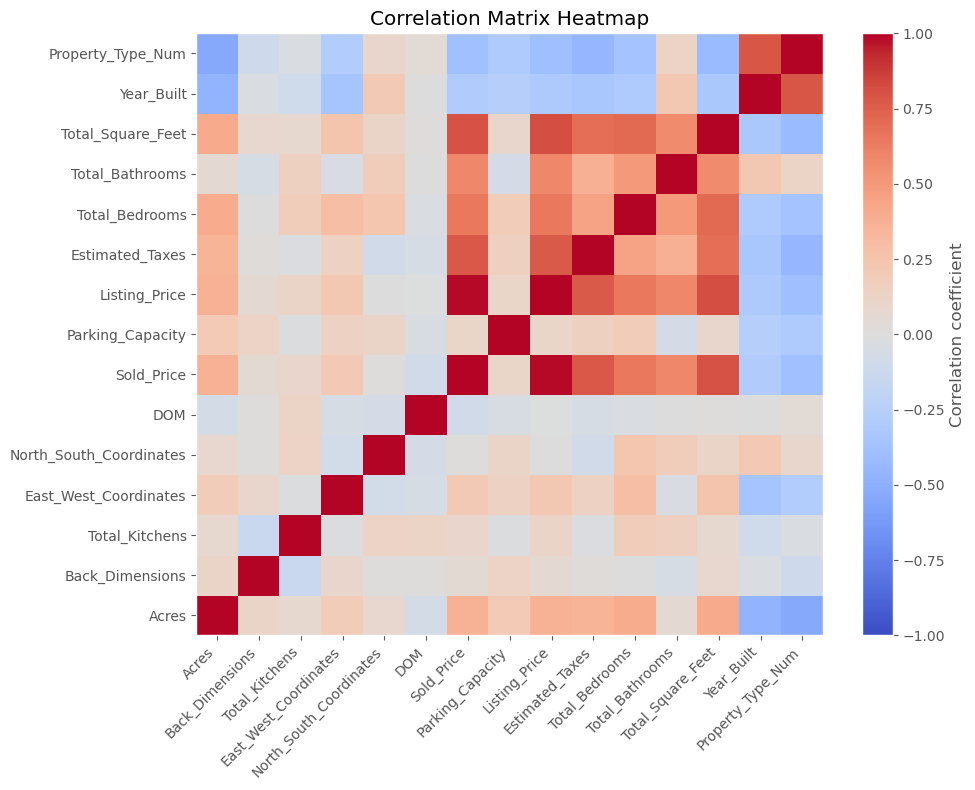

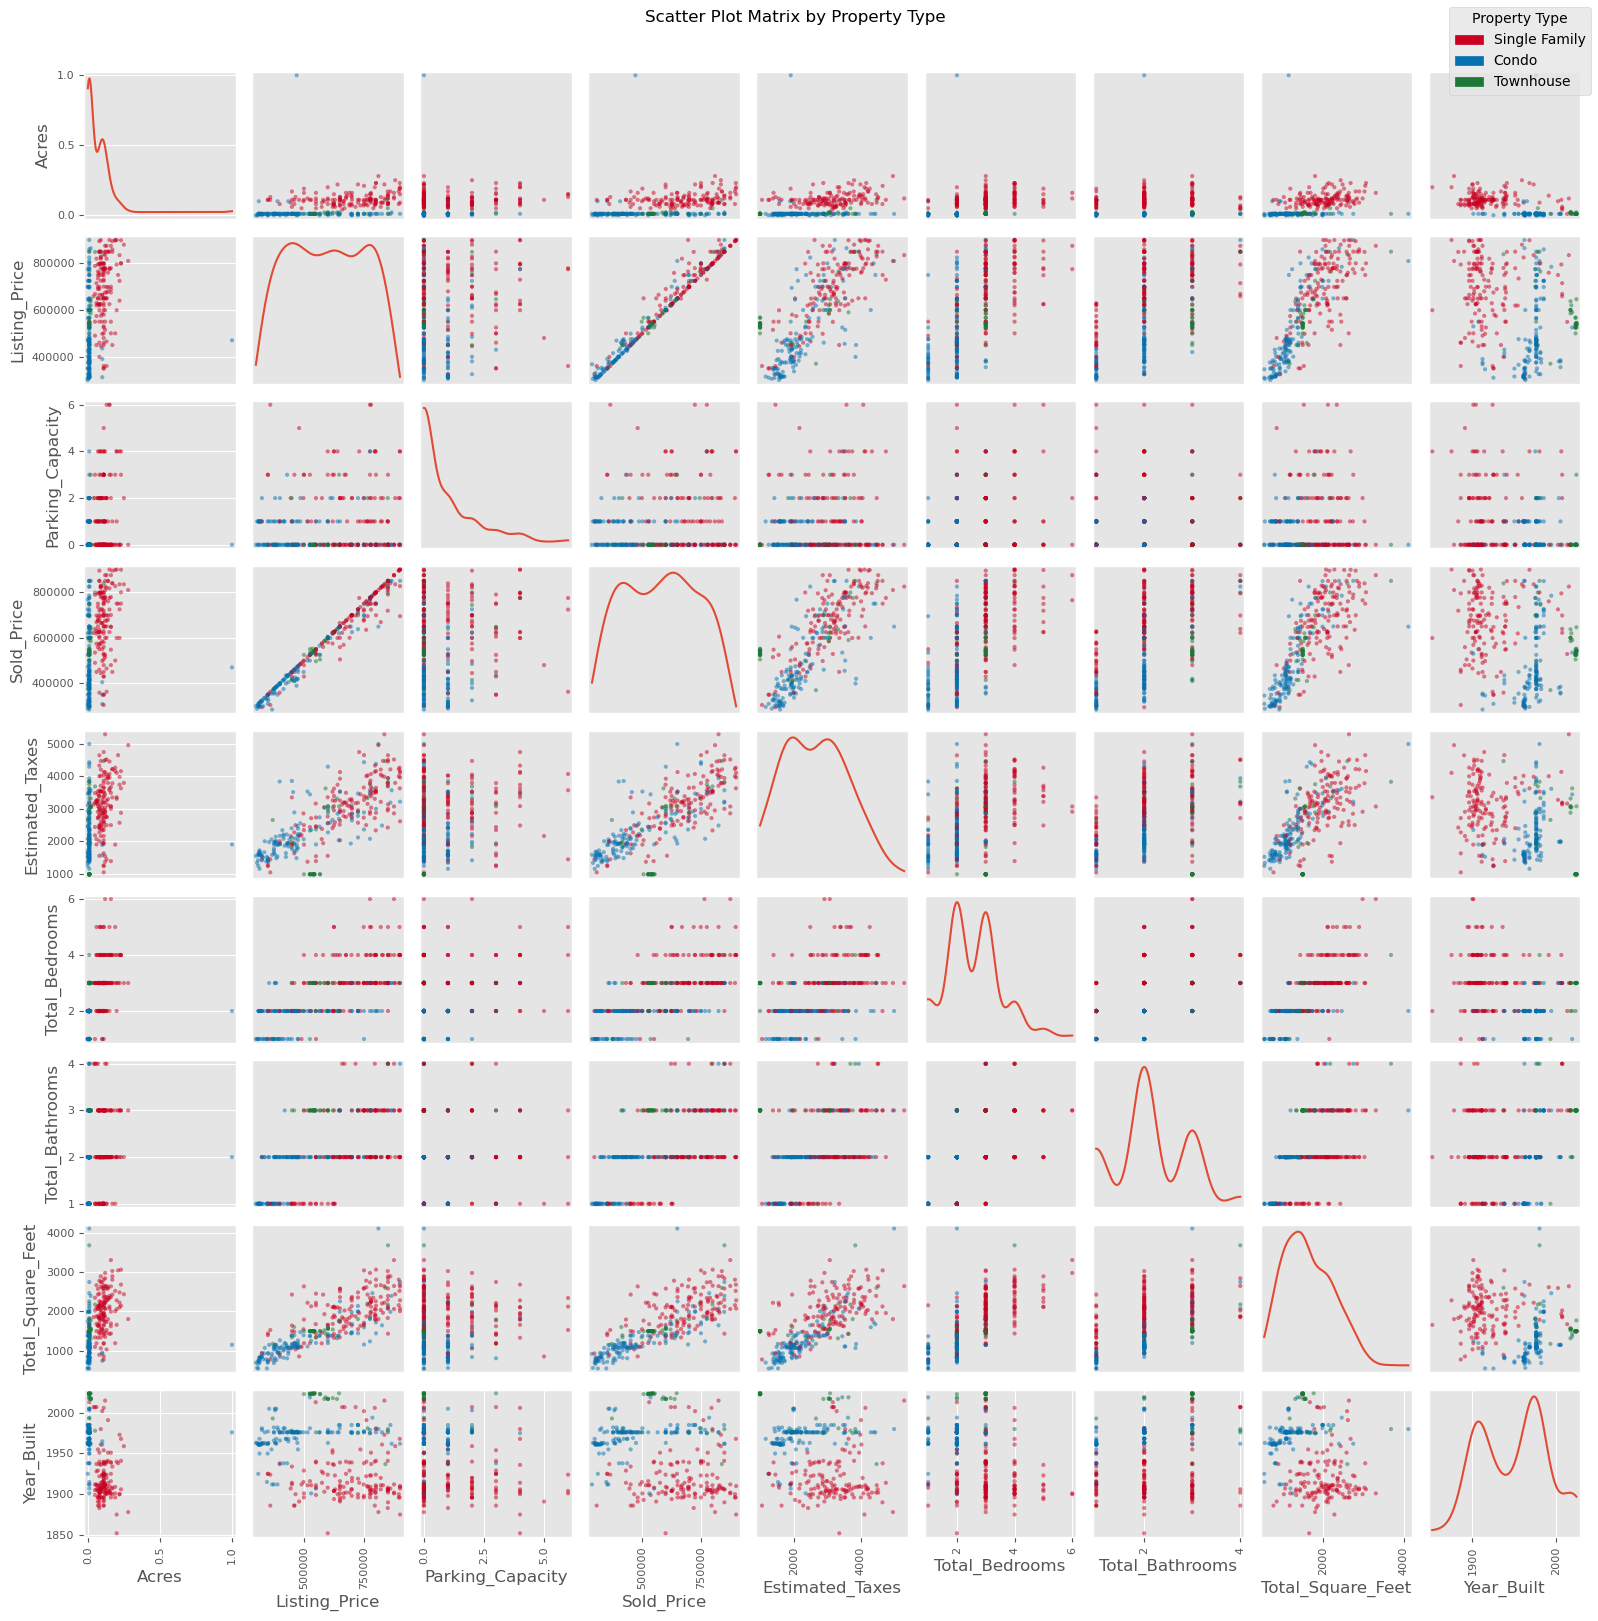

In [48]:
# Color map for property types
color_dict = {
    "Single Family": "#ca0020",
    "Condo":         "#0571b0",
    "Townhouse":     "#1b7837"
}
type_color_map = filtered_df["Property_Type"].map(color_dict)
legend_handles = [mpatches.Patch(color=color, label=label) 
                  for label, color in color_dict.items()]

# Bar Chart of Property Types
type_counts = filtered_df['Property_Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(type_counts.index, type_counts.values, color=[color_dict[t] for t in type_counts.index])

for i, val in enumerate(type_counts.values):
    ax.text(i, val + 1, str(val), ha='center')

ax.set_title('Number of Listings by Property Type')
ax.set_xlabel('Property Type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation Matrix Heatmap
numeric_cols = filtered_df.select_dtypes(include='number').columns.tolist()
corr_matrix = filtered_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
c = ax.pcolor(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(c, ax=ax, label='Correlation coefficient')

ticks = np.arange(0.5, len(corr_matrix.columns), 1)
ax.set_xticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(ticks)
ax.set_yticklabels(corr_matrix.columns)
ax.set_title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Scatter Plot Matrix by Property Type
scatter_cols = ['Acres', 'Listing_Price', 'Parking_Capacity', 'Sold_Price',
                'Estimated_Taxes', 'Total_Bedrooms', 'Total_Bathrooms',
                'Total_Square_Feet', 'Year_Built']

pd.plotting.scatter_matrix(filtered_df[scatter_cols], figsize=(16, 16),
                           diagonal='kde', color=type_color_map, alpha=0.5)

plt.gcf().legend(handles=legend_handles, loc='upper right', title='Property Type')
plt.suptitle('Scatter Plot Matrix by Property Type', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation Question**
- Interpret the correlation matrix; what are the most and least correlated features? Which features do you expect to have most significance in price? 
- What does the scatter matrix show? Which features are most and least correlated to one another.
- How do you compare the scatter matrix to the correlation matrix?
- Explain why the features of your choice might have the most significance?

**Your Interpretation:**

**Correlation Matrix:**
`Listing_Price`, `Estimated_Taxes`, `Total_Square_Feet`, `Total_Bathrooms`, and `Total_Bedrooms` 
move most closely with `Sold_Price`. `Acres`, `Back_Dimensions`, `DOM`, and `Total_Kitchens` 
have almost no effect on price. `Property_Type_Num` has a slight negative correlation, meaning 
Single Family homes (0) tend to sell for more than Condos (1) and Townhouses (2).

**Scatter Matrix:**
The plots confirm the same thing — bigger homes, higher taxes, and higher listing prices 
all lead to higher sold prices. Lot size and parking show no clear pattern.

**Scatter Matrix vs Correlation Matrix:**
The heatmap gives us one number to compare features quickly. The scatter matrix lets us 
actually see the relationship — whether it's a straight line, curved, or just random dots.

**Why these features matter most:**
Sellers price homes based on market value, taxes are set by how much the home is worth, 
and bigger homes with more bathrooms and bedrooms simply cost more. All these features 
directly reflect the value of the home.



### Task 4: Geospatial plot
Two of the variables are the East-West Coordinates and North-South Coordinates of each listing. These values are extracted from the latitude and longitude of each listing in Salt Lake City. Create a scatterplot of these two variables. Use color to indicate the listing price of the house. 

What can you say about the relation between the location and the listing price?  

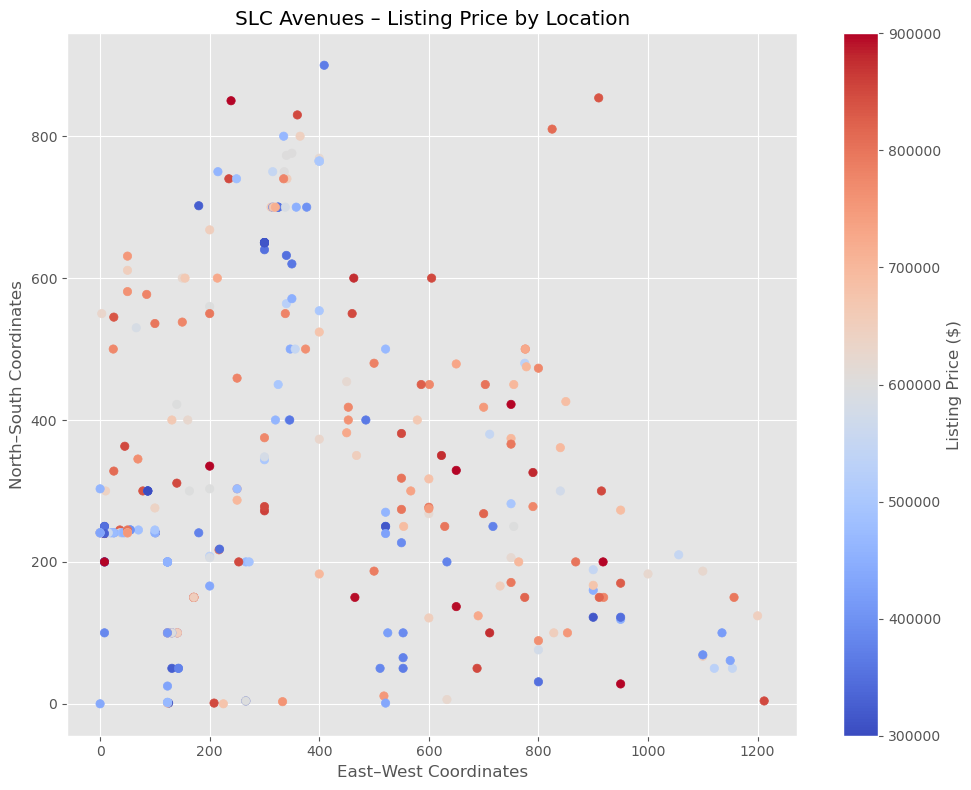

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    filtered_df['East_West_Coordinates'],
    filtered_df['North_South_Coordinates'],
    c=filtered_df['Listing_Price'],
    cmap='coolwarm'
)

plt.colorbar(scatter, ax=ax, label='Listing Price ($)')
ax.set_title('SLC Avenues – Listing Price by Location')
ax.set_xlabel('East–West Coordinates')
ax.set_ylabel('North–South Coordinates')
plt.tight_layout()
plt.show()

**Your Interpretation:** 
Houses in the eastern part of the neighborhood tend to have higher listing prices, 
while the western side has more affordable homes. The north-south direction does not 
show a strong pattern on its own. Overall, location does play a role in pricing, 
with the pricier homes clustering toward the east.

### Task 5: Simple  Linear Regression 
Use the `ols` function from the [statsmodels](http://www.statsmodels.org/stable/index.html) package to do several simple linear regressions. Each model should be of the form Sold_Price = beta_0 + beta_1 * x, where x is one of the predictor variables that you choose and the target is predicting Sold_Price. Do this for at least three different predictor variables (other than Sold_Price).

$$
\text{Sold Price} = \beta_0 + \beta_1 x, 
$$

The best predictor can be identified as the variable that results in the highest R^2 value in the regression model. 
- You'll find the best predictor of the Sold_Price. Is it what you expected from Task 3? 
- Report the R-squared value for this model (`Sold_Price ~ BestPredictor`) and give an interpretation for its meaning.
- Also give an interpretation of $\beta_1$ for the model of Sold_Price best predictor.
- Make a scatterplot of Sold_Price ~ Listing_Price and overlay the prediction coming from your regression model.

**Hint.** You can try the variables with highest correlations with Sold_Price to find the best predictor.

Listing_Price             R-squared = 0.9707
Estimated_Taxes           R-squared = 0.6024
Total_Square_Feet         R-squared = 0.6370
Total_Bathrooms           R-squared = 0.3381
                            OLS Regression Results                            
Dep. Variable:             Sold_Price   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 1.018e+04
Date:                Fri, 20 Feb 2026   Prob (F-statistic):          1.89e-237
Time:                        23:48:41   Log-Likelihood:                -3615.2
No. Observations:                 309   AIC:                             7234.
Df Residuals:                     307   BIC:                             7242.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    st

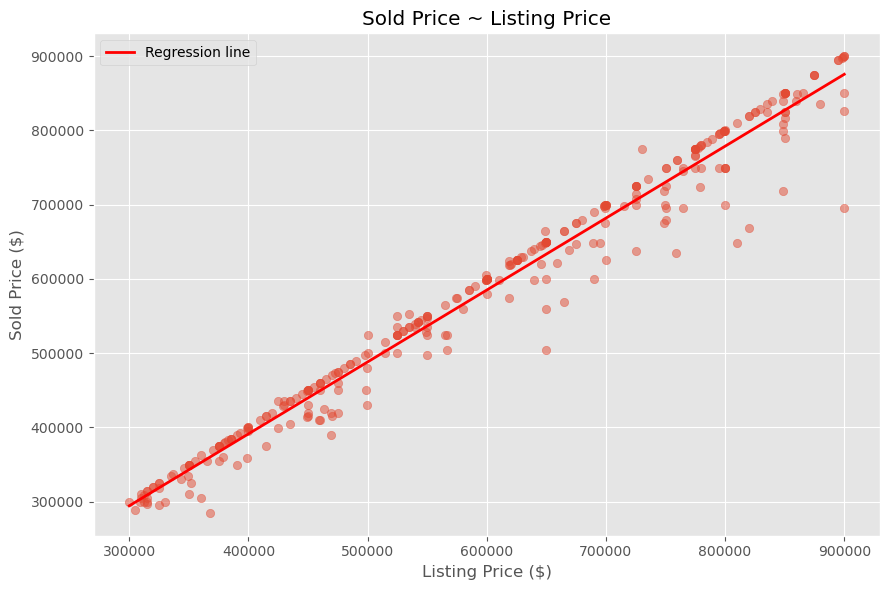

In [56]:
predictors = ['Listing_Price', 'Estimated_Taxes', 'Total_Square_Feet', 'Total_Bathrooms']

best_r2 = 0
for pred in predictors:
    model = sm.ols(f'Sold_Price ~ {pred}', data=filtered_df).fit()
    print(f'{pred:25s} R-squared = {model.rsquared:.4f}')
    if model.rsquared > best_r2:
        best_r2 = model.rsquared
        best_model = model

# Print the best model summary
print(best_model.summary())

# Scatterplot: Sold_Price ~ Listing_Price with regression line
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(filtered_df['Listing_Price'], filtered_df['Sold_Price'], alpha=0.5)

x_range = np.linspace(filtered_df['Listing_Price'].min(),
                      filtered_df['Listing_Price'].max(), 200)
y_pred = best_model.params['Intercept'] + best_model.params['Listing_Price'] * x_range
ax.plot(x_range, y_pred, color='red', linewidth=2, label='Regression line')

ax.set_title('Sold Price ~ Listing Price')
ax.set_xlabel('Listing Price ($)')
ax.set_ylabel('Sold Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Your Interpretation:**

***Best Predictor:***
Listing Price turned out to be the best predictor, which is what we expected from 
Task 3 since it had the strongest correlation with Sold Price.

***R-squared Interpretation:***
The R-squared value is very high, meaning the listing price alone explains almost all 
of the variation in the sold price. Sellers in this neighborhood know what their home is worth.

***Beta Interpretation:***
Beta is very close to 1, meaning for every extra dollar in listing price, the home 
sells for almost exactly that same dollar more.

***Scatter Plot:***
The dots follow the regression line very closely from bottom left to top right, 
confirming that homes in this neighborhood almost always sell for very close to 
what they were listed for.

### Task 6: Multilinear Regression 
Develop a multilinear regression model for house prices in this neighborhood. We could use this to come up with a list price for houses coming on the market, so do not include the list price in your model and, for now, ignore the categorical variable Property_Type or it's one-hot encodings. Your model should be of the form:
$$
\text{Sold Price} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots +  \beta_n x_n, 
$$
where $x_i$ are predictive variables.


**Question 1**: If we wanted to start a 'house flipping' company, we'd have to be able to do a better job of predicting the sold price than the list price does. How does your new model compare to the model in Task 5 just using list price?

Next look at the difference between list price and sold price explicitly. Calculate two new columns for your dataset. `DiffPriceAbsolute` and `DiffPriceRelative`.

* `DiffPriceAbsolute` - This is difference between sold price and list price. If it is positive, that means the house sold for more than it was listed at.
* `DiffPriceRelative` - This is the relative difference between sold price and list price. A value of 1.1 here means that the house sold for 110% of the listing price, and 0.9 means the house sold for 90% of the listing price.

Now, create two new models. One to predict `DiffPriceAbsolute`, and one to predict `DiffPriceRelative`. Use the same predictive variables as in the last model.


**Question 2**: Which of these two new models makes better predictions?

**Question 3**: Based on your answer to question two, why are these models different/the same?

To help justify your answer to question 3, train two models to predict `DiffPriceAbsolute` and `DiffPriceRelative` based on just `Sold_Price`. In addition, for each model make a scatterplots similar to Task 5 for these models.

                            OLS Regression Results                            
Dep. Variable:             Sold_Price   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     134.9
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           1.20e-94
Time:                        23:53:32   Log-Likelihood:                -3925.1
No. Observations:                 309   AIC:                             7868.
Df Residuals:                     300   BIC:                             7902.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          6.723e+05   3.11e+0

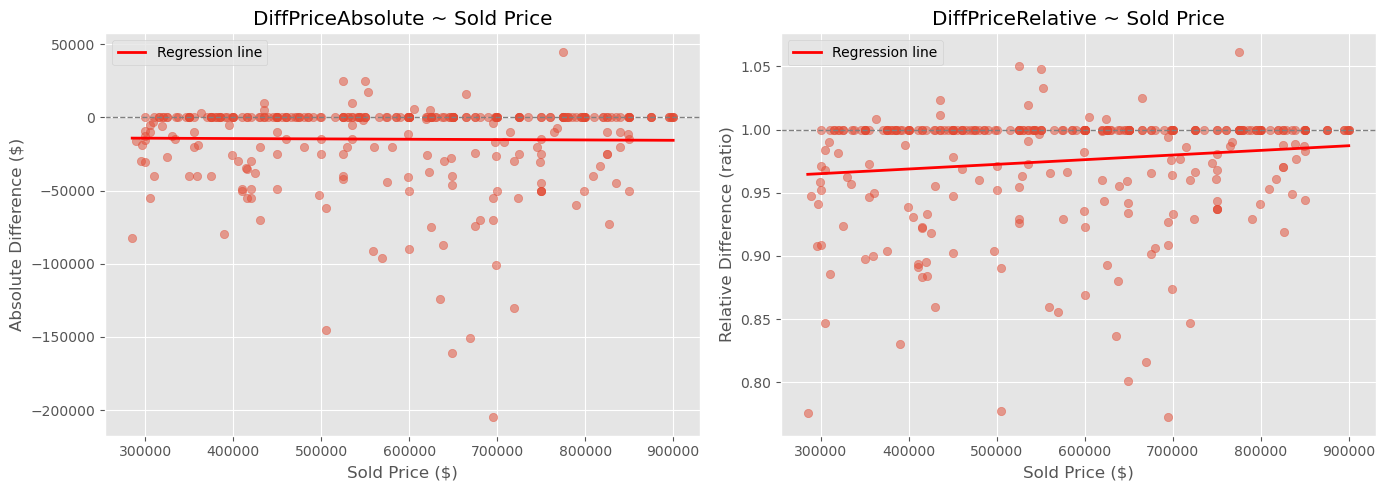

In [ ]:
# Multilinear model without Listing_Price or Property_Type
multi_model = sm.ols(
    'Sold_Price ~ Total_Square_Feet + Estimated_Taxes + Total_Bathrooms + '
    'Total_Bedrooms + Year_Built + Acres + DOM + Parking_Capacity',
    data=filtered_df
).fit()
print(multi_model.summary())

# Compare to Task 5
print(f'Task 5 Listing_Price R-squared  : {best_model.rsquared:.4f}')
print(f'Task 6 Multilinear   R-squared  : {multi_model.rsquared:.4f}')

# New columns
filtered_df['DiffPriceAbsolute'] = filtered_df['Sold_Price'] - filtered_df['Listing_Price']
filtered_df['DiffPriceRelative'] = filtered_df['Sold_Price'] / filtered_df['Listing_Price']

# Predict DiffPriceAbsolute and DiffPriceRelative
predictors_str = ('Total_Square_Feet + Estimated_Taxes + Total_Bathrooms + '
                  'Total_Bedrooms + Year_Built + Acres + DOM + Parking_Capacity')

abs_model = sm.ols(f'DiffPriceAbsolute ~ {predictors_str}', data=filtered_df).fit()
rel_model = sm.ols(f'DiffPriceRelative ~ {predictors_str}', data=filtered_df).fit()

print(f'DiffPriceAbsolute R-squared: {abs_model.rsquared:.4f}')
print(f'DiffPriceRelative R-squared: {rel_model.rsquared:.4f}')

# Predict using just Sold_Price
abs_sold_model = sm.ols('DiffPriceAbsolute ~ Sold_Price', data=filtered_df).fit()
rel_sold_model = sm.ols('DiffPriceRelative ~ Sold_Price', data=filtered_df).fit()

print(f'DiffPriceAbsolute ~ Sold_Price R-squared: {abs_sold_model.rsquared:.4f}')
print(f'DiffPriceRelative ~ Sold_Price R-squared: {rel_sold_model.rsquared:.4f}')

# Scatterplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(filtered_df['Sold_Price'], filtered_df['DiffPriceAbsolute'], alpha=0.5)
x_range = np.linspace(filtered_df['Sold_Price'].min(),
                      filtered_df['Sold_Price'].max(), 200)
y_abs = abs_sold_model.params['Intercept'] + abs_sold_model.params['Sold_Price'] * x_range
axes[0].plot(x_range, y_abs, color='red', linewidth=2, label='Regression line')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('DiffPriceAbsolute ~ Sold Price')
axes[0].set_xlabel('Sold Price ($)')
axes[0].set_ylabel('Absolute Difference ($)')
axes[0].legend()

axes[1].scatter(filtered_df['Sold_Price'], filtered_df['DiffPriceRelative'], alpha=0.5)
y_rel = rel_sold_model.params['Intercept'] + rel_sold_model.params['Sold_Price'] * x_range
axes[1].plot(x_range, y_rel, color='red', linewidth=2, label='Regression line')
axes[1].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('DiffPriceRelative ~ Sold Price')
axes[1].set_xlabel('Sold Price ($)')
axes[1].set_ylabel('Relative Difference (ratio)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Your Interpretation:** TODO - answer Questions 1, 2, and 3

***Question 1:***
The multilinear model performs worse than just using listing price. Physical features 
alone are not enough to predict sold price as accurately as the listing price does.

***Question 2:***
DiffPriceRelative makes better predictions because its R-squared is higher.

***Question 3:***
DiffPriceAbsolute grows with the price of the home , expensive homes have bigger 
dollar swings. DiffPriceRelative fixes this by using a ratio instead, making it 
more consistent across all price ranges. The scatter plots show this clearly
DiffPriceAbsolute trends upward with Sold Price, while DiffPriceRelative stays 
flat around 1.0.

### Task 7: Incorporating a categorical variable

Above, we considered houses, townhouses, and condos together, but here we'll distinguish between them. Consider the three regression models: 
$$
\text{Sold\_Price} = \beta_0 + \beta_1 \text{Property\_Type\_num}
$$
, 
$$
\text{Sold\_Price} = \beta_0  + \beta_1 \text{Property\_Type\_num} + \beta_2 \text{Total\_Square\_Feet}
$$
and 
$$
\text{Sold\_Price} = \beta_0  + \beta_1 \text{Feature1} + \beta_2 \text{Feature2}
$$
From the first model, it would appear that Property type is significant in predicting the sold price. On the other hand, the second model indicates that when you take into account total square footage, property type is no longer predictive. 
- Explain this.
- Make a scatterplot of Total_Square_Feet vs. Sold_Price where the house types are colored differently to illustrate your explanation. 

Now, we want to improve the prediction of sold price, without directly usig a price-based feature. From data analysis (task 3) find the best two predictive features; except for Listing_Price, and fit a model to predict the Sold_Price, as your Model 3. 
- Explain how these features changed the performance.
- Make scatterplots of Feature1 vs. Sold_Price and Feature2 vs. Sold_Price. How do you interpret the new plot?



Model 1: Sold_Price ~ Property_Type_Num
R-squared: 0.1498
Model 2: Sold_Price ~ Property_Type_Num + Total_Square_Feet
R-squared: 0.6395


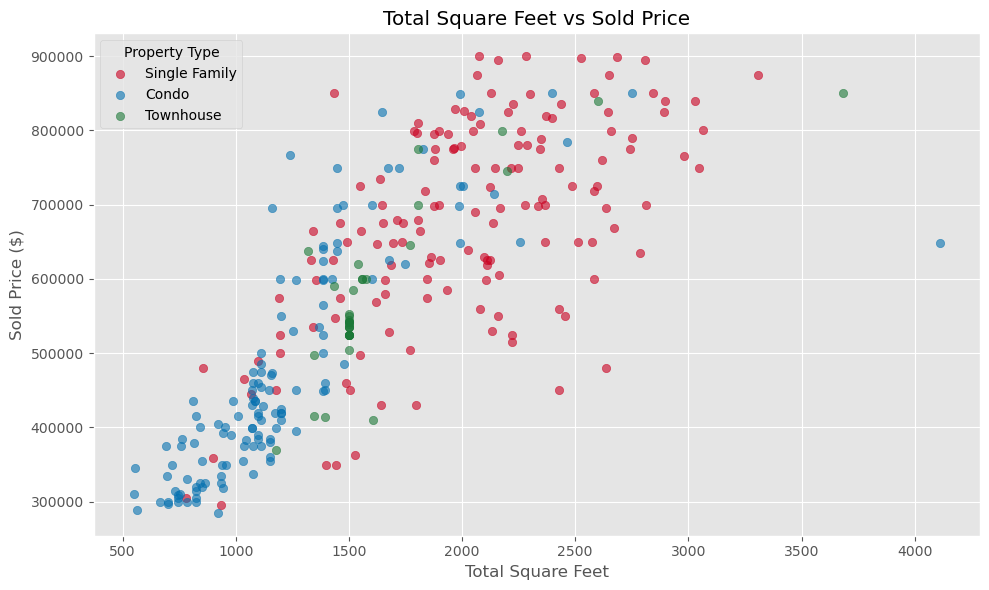

Model 3: Sold_Price ~ Total_Square_Feet + Estimated_Taxes
R-squared: 0.7337
Model 1 R-squared: 0.1498
Model 2 R-squared: 0.6395
Model 3 R-squared: 0.7337


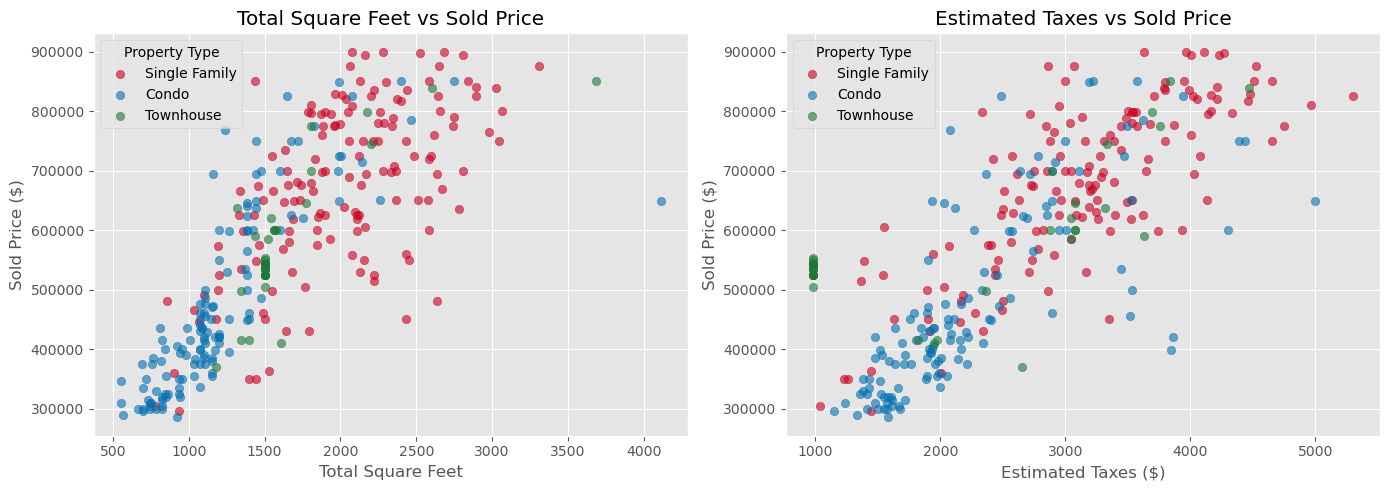

In [58]:
# Model 1: Sold_Price ~ Property_Type_Num
model1 = sm.ols('Sold_Price ~ Property_Type_Num', data=filtered_df).fit()
print('Model 1: Sold_Price ~ Property_Type_Num')
print(f'R-squared: {model1.rsquared:.4f}')

# Model 2: Sold_Price ~ Property_Type_Num + Total_Square_Feet
model2 = sm.ols('Sold_Price ~ Property_Type_Num + Total_Square_Feet', data=filtered_df).fit()
print('Model 2: Sold_Price ~ Property_Type_Num + Total_Square_Feet')
print(f'R-squared: {model2.rsquared:.4f}')

# Scatterplot: Total_Square_Feet vs Sold_Price colored by Property_Type
fig, ax = plt.subplots(figsize=(10, 6))
for ptype, color in color_dict.items():
    subset = filtered_df[filtered_df['Property_Type'] == ptype]
    ax.scatter(subset['Total_Square_Feet'], subset['Sold_Price'],
               color=color, label=ptype, alpha=0.6)

ax.set_title('Total Square Feet vs Sold Price')
ax.set_xlabel('Total Square Feet')
ax.set_ylabel('Sold Price ($)')
ax.legend(title='Property Type')
plt.tight_layout()
plt.show()

# Model 3: Best two non-price features from Task 3
model3 = sm.ols('Sold_Price ~ Total_Square_Feet + Estimated_Taxes', data=filtered_df).fit()
print('Model 3: Sold_Price ~ Total_Square_Feet + Estimated_Taxes')
print(f'R-squared: {model3.rsquared:.4f}')

# Compare all models
print(f'Model 1 R-squared: {model1.rsquared:.4f}')
print(f'Model 2 R-squared: {model2.rsquared:.4f}')
print(f'Model 3 R-squared: {model3.rsquared:.4f}')

# Scatterplots: Feature1 and Feature2 vs Sold_Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ptype, color in color_dict.items():
    subset = filtered_df[filtered_df['Property_Type'] == ptype]
    axes[0].scatter(subset['Total_Square_Feet'], subset['Sold_Price'],
                    color=color, label=ptype, alpha=0.6)
    axes[1].scatter(subset['Estimated_Taxes'], subset['Sold_Price'],
                    color=color, label=ptype, alpha=0.6)

axes[0].set_title('Total Square Feet vs Sold Price')
axes[0].set_xlabel('Total Square Feet')
axes[0].set_ylabel('Sold Price ($)')
axes[0].legend(title='Property Type')

axes[1].set_title('Estimated Taxes vs Sold Price')
axes[1].set_xlabel('Estimated Taxes ($)')
axes[1].set_ylabel('Sold Price ($)')
axes[1].legend(title='Property Type')

plt.tight_layout()
plt.show()

**Your Interpretation:** 

***Model 1 vs Model 2:***
Property type alone seems to predict sold price because condos are smaller and 
cheaper, while single family homes are larger and more expensive. But once we add 
total square footage, property type loses its importance — it turns out size is 
what really drives the price, not the type of home itself.

***Model 3:***
Using Total Square Feet and Estimated Taxes together gives a much better result 
than Model 1 and 2. Both features directly reflect how much a home is worth — 
bigger homes cost more, and higher taxes mean a higher assessed value.

***Scatter Plots:***
Both plots show a clear upward trend with Sold Price. Single family homes cluster 
at the higher end of both axes, while condos sit at the lower end, which is 
consistent with everything we have seen so far.